# Etapa 2 — Análise Exploratória de Dados

Entrada: os CSVs que a Etapa 1 gravou em `../data/raw/`.
Saída: uma tabela horária limpa em `../data/processed/dataset.csv`, mais os
gráficos e as conclusões que sustentam o que você vai afirmar.

As seções abaixo são um roteiro, não uma receita. Responda as perguntas de
cada uma com código e, no fim, em texto. Acrescente seções se quiser.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

DIR_RAW = Path("..") / "data" / "raw"
DIR_PROC = Path("..") / "data" / "processed"
DIR_PROC.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 4)

> **Sobre os dados.** A previsão de onda e vento muda todo dia, então os CSVs
> usados aqui foram coletados em **01/10/2026** e estão versionados em
> `data/raw/`. A janela de previsão é de 01 a 07/10/2026. Rodar o scraper de
> novo troca a semana e as conclusões abaixo deixam de valer.

## 1. Carregar os CSVs

Leia os quatro arquivos de `../data/raw/`.

- Quantas linhas tem cada um? O número faz sentido para o período coletado?
- Os tipos vieram certos, ou datas e números chegaram como texto?
- Há colunas vazias, ou linhas duplicadas?

In [2]:
mares_ano = pd.read_csv(DIR_RAW / "mares_2025.csv")
mares_prev = pd.read_csv(DIR_RAW / "mares_previsao.csv")
ondas = pd.read_csv(DIR_RAW / "ondas.csv")
vento = pd.read_csv(DIR_RAW / "vento.csv")

tabelas = {"mares_2025": mares_ano, "mares_previsao": mares_prev, "ondas": ondas, "vento": vento}
pd.DataFrame({
    nome: {
        "linhas": len(df),
        "colunas": df.shape[1],
        "nulos": int(df.isna().sum().sum()),
        "duplicadas": int(df.duplicated().sum()),
        "dias": df["data"].nunique(),
    }
    for nome, df in tabelas.items()
}).T

,linhas,colunas,nulos,duplicadas,dias
mares_2025,1410,8,0,0,365
mares_previsao,236,8,0,0,61
ondas,168,4,0,0,7
vento,168,4,0,0,7


In [3]:
for nome, df in tabelas.items():
    print(f"--- {nome}")
    print(df.dtypes.to_string(), end="\n\n")

--- mares_2025
data               str
hora               str
tipo               str
altura_m       float64
coeficiente      int64
idade_lua        int64
nascer_sol         str
por_sol            str

--- mares_previsao
data               str
hora               str
tipo               str
altura_m       float64
coeficiente      int64
idade_lua        int64
nascer_sol         str
por_sol            str

--- ondas
data                str
hora                str
altura_m        float64
direcao_onda        str

--- vento
data                 str
hora                 str
vento_kmh        float64
direcao_vento        str



**Leitura.**

- **Os números fazem sentido para o período.** Onda e vento têm 168 linhas =
  7 dias × 24 h. A tábua de 2025 tem 1410 marés em 365 dias, ou seja 3,86 por
  dia, e não 4. O ciclo da maré dura ~12h25min, então ela atrasa ~50 min por
  dia e, de tempos em tempos, um dia fica com só 3 eventos. Isso dá
  365 × 24 / 12,42 ≈ 705 marés altas por ano, e a tabela tem exatamente 705
  altas e 705 baixas.
- **Nulos e duplicatas:** nenhum. O scraper já pula as células vazias da tábua.
- **Tipos:** os números chegaram como `float`/`int`, porque a vírgula decimal
  foi convertida na Etapa 1. Data, hora e horários do sol ainda são texto e
  precisam virar `datetime`.

## 2. Limpeza

Deixe cada tabela num estado em que dá para confiar.

- Datas e horas: viram `datetime`? Vale montar uma coluna única de data + hora?
- Decimais: o site usa vírgula. Isso já foi resolvido na Etapa 1 ou sobrou aqui?
- O que fazer com nulos: descartar a linha, preencher, ou manter e documentar?
- Duplicatas: existem? De onde vieram?

In [4]:
def para_datetime(data, hora):
    return pd.to_datetime(data + " " + hora, format="%Y-%m-%d %H:%M")


def limpar_mares(df):
    df = df.copy()
    df["momento"] = para_datetime(df["data"], df["hora"])
    df["nascer_sol"] = para_datetime(df["data"], df["nascer_sol"])
    df["por_sol"] = para_datetime(df["data"], df["por_sol"])
    df["data"] = pd.to_datetime(df["data"])
    df["tipo"] = df["tipo"].astype("category")
    return df.drop(columns="hora").sort_values("momento").reset_index(drop=True)


def limpar_previsao(df):
    df = df.copy()
    df["momento"] = para_datetime(df["data"], df["hora"])
    return df.drop(columns=["data", "hora"]).sort_values("momento").reset_index(drop=True)


mares_ano = limpar_mares(mares_ano)
mares_prev = limpar_mares(mares_prev)
ondas = limpar_previsao(ondas)
vento = limpar_previsao(vento)
mares_prev.head()

,data,tipo,altura_m,coeficiente,idade_lua,nascer_sol,por_sol,momento
0,2026-10-01,baixa,0.4,64,19,2026-10-01 05:02:00,2026-10-01 17:15:00,2026-10-01 00:24:00
1,2026-10-01,alta,2.3,64,19,2026-10-01 05:02:00,2026-10-01 17:15:00,2026-10-01 06:45:00
2,2026-10-01,baixa,0.6,64,19,2026-10-01 05:02:00,2026-10-01 17:15:00,2026-10-01 12:54:00
3,2026-10-01,alta,2.1,64,19,2026-10-01 05:02:00,2026-10-01 17:15:00,2026-10-01 18:57:00
4,2026-10-02,baixa,0.5,50,20,2026-10-02 05:02:00,2026-10-02 17:14:00,2026-10-02 01:14:00


In [5]:
for nome, df in {"ondas": ondas, "vento": vento}.items():
    passos = df["momento"].diff().dropna().value_counts()
    print(f"{nome}: {df['momento'].min()} → {df['momento'].max()} | passos: {passos.to_dict()}")

print("ondas e vento nas mesmas horas:", ondas["momento"].equals(vento["momento"]))

for nome, df in {"mares_2025": mares_ano, "mares_previsao": mares_prev}.items():
    repetidas = (df["tipo"] == df["tipo"].shift()).sum()
    print(f"{nome}: {repetidas} marés seguidas do mesmo tipo")

ondas: 2026-10-01 00:00:00 → 2026-10-07 23:00:00 | passos: {Timedelta('0 days 01:00:00'): 167}
vento: 2026-10-01 00:00:00 → 2026-10-07 23:00:00 | passos: {Timedelta('0 days 01:00:00'): 167}
ondas e vento nas mesmas horas: True
mares_2025: 0 marés seguidas do mesmo tipo
mares_previsao: 0 marés seguidas do mesmo tipo


**Decisões de limpeza.**

- **Data + hora viraram uma coluna só, `momento` (`datetime`).** É a chave da
  junção na seção 4. Nascer e pôr do sol também viraram `datetime` do dia, para
  dar para comparar direto com `momento`.
- **Vírgula decimal:** resolvida na Etapa 1 (`"2,3"` → `2.3`), não sobrou nada aqui.
- **Nulos:** não há. **Duplicatas:** não há. A grade de onda e vento é contínua
  (todos os passos são de 1 h) e as duas cobrem exatamente as mesmas 168 horas.
- **Consistência física:** a maré tem que alternar alta → baixa → alta. Não há
  duas seguidas do mesmo tipo, então nenhum evento se perdeu no scraping,
  inclusive na emenda entre os meses.

## 3. Explorar cada tabela separadamente

Antes de juntar, entenda cada fonte.

**Marés** — como a altura se distribui entre marés altas e baixas? O
coeficiente varia ao longo do ano com algum padrão? Ele tem relação com a
fase da lua?

**Ondas** — qual a faixa de altura na janela coletada? Há padrão por hora do
dia, ou a variação é só por dia?

**Vento** — quais horas são mais calmas? A direção predominante muda ao longo
do dia? (Vento da terra para o mar e vento do mar para a terra fazem coisas
opostas com a onda.)

Um gráfico por pergunta. Escreva o que você leu nele.

### Marés

correlação de Pearson coeficiente × idade_lua: 0.024
       count  mean   std  min  25%  50%  75%  max
tipo                                             
alta   705.0  2.20  0.24  1.7  2.0  2.2  2.4  2.8
baixa  705.0  0.54  0.22  0.0  0.4  0.5  0.7  1.0


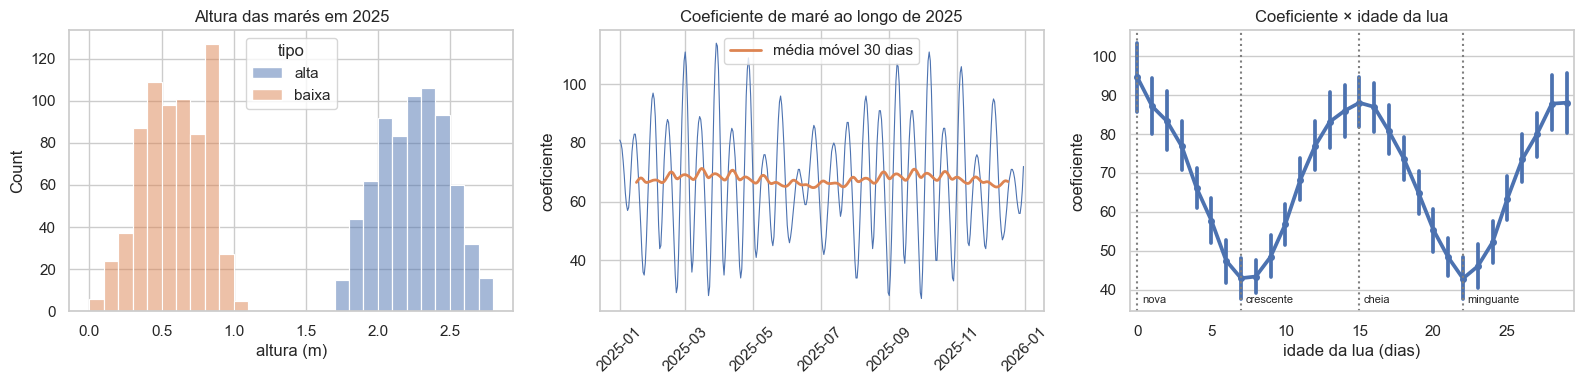

In [6]:
dias = mares_ano.drop_duplicates("data")[["data", "coeficiente", "idade_lua"]]

fig, ax = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(data=mares_ano, x="altura_m", hue="tipo", binwidth=0.1, ax=ax[0])
ax[0].set(title="Altura das marés em 2025", xlabel="altura (m)")

ax[1].plot(dias["data"], dias["coeficiente"], lw=0.8)
ax[1].plot(dias["data"], dias["coeficiente"].rolling(30, center=True).mean(), lw=2, label="média móvel 30 dias")
ax[1].set(title="Coeficiente de maré ao longo de 2025", ylabel="coeficiente")
ax[1].legend()
ax[1].tick_params(axis="x", rotation=45)

sns.pointplot(data=dias, x="idade_lua", y="coeficiente", ax=ax[2], markersize=3)
for x, nome in [(0, "nova"), (7, "crescente"), (15, "cheia"), (22, "minguante")]:
    ax[2].axvline(x, color="gray", ls=":")
    ax[2].text(x + 0.3, 0.03, nome, fontsize=8, transform=ax[2].get_xaxis_transform())
ax[2].set(title="Coeficiente × idade da lua", xlabel="idade da lua (dias)")
ax[2].set_xticks(range(0, 30, 5))
plt.tight_layout()

print("correlação de Pearson coeficiente × idade_lua:", round(dias["coeficiente"].corr(dias["idade_lua"]), 3))
print(mares_ano.groupby("tipo", observed=True)["altura_m"].describe().round(2))

**Leitura.**

- **Altura:** as marés altas ficam entre 1,7 e 2,8 m (média 2,2) e as baixas
  entre 0,0 e 1,0 m (média 0,54). Os dois grupos não se sobrepõem, e a
  diferença entre eles é de ~1,7 m: é bastante água entrando e saindo da praia
  duas vezes por dia.
- **Ao longo do ano** o coeficiente oscila o tempo todo entre ~40 e ~110, mas a
  média móvel quase não muda (66 a 72 em todos os meses). **A maré não tem
  estação.** Os picos mais altos aparecem perto dos equinócios (114 em março,
  111 em outubro), quando Sol e Lua se alinham com o equador.
- **Com a lua, a relação é forte, mas não é linear.** O coeficiente atinge o
  pico na lua nova (dia 0/29, ~95) e na cheia (dia ~15, ~88), que são as
  *marés de sizígia*, e cai nas luas crescente e minguante (dias 7–8 e 22,
  ~43). Mesmo assim, a correlação de Pearson dá **0,03**, porque ela só mede
  relação em linha reta e essa curva sobe e desce duas vezes. Lição: correlação
  perto de zero não quer dizer que não há relação.

### Ondas

variância explicada pelo dia: 55%
hora
0    1.10
1    1.32
2    1.32
Name: média por hora % 3, dtype: float64


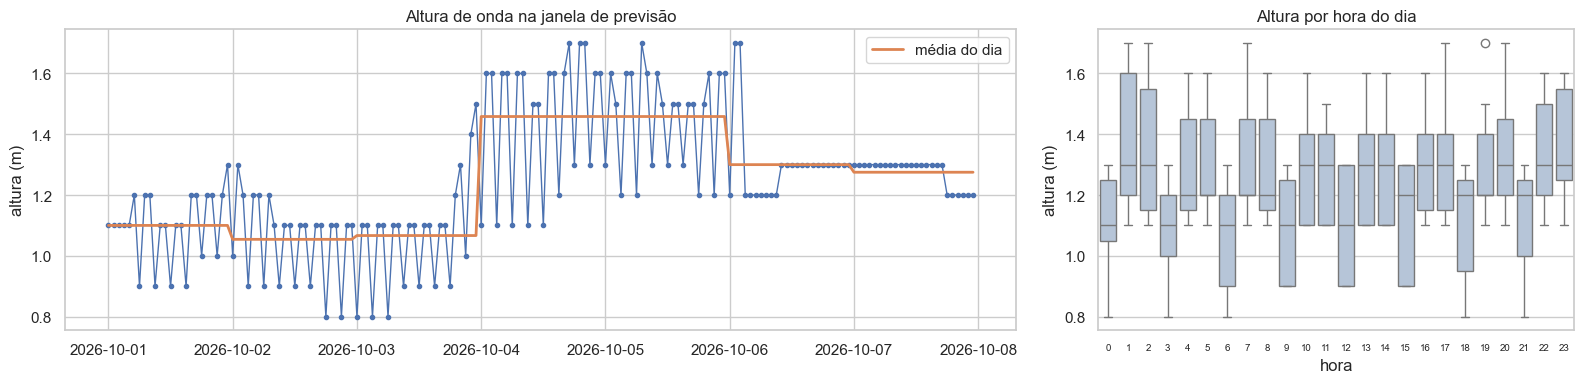

In [7]:
ondas["hora"] = ondas["momento"].dt.hour
ondas["dia"] = ondas["momento"].dt.strftime("%d/%m")

fig, ax = plt.subplots(1, 2, figsize=(16, 4), gridspec_kw={"width_ratios": [2, 1]})
ax[0].plot(ondas["momento"], ondas["altura_m"], marker=".", lw=1)
ax[0].plot(ondas["momento"], ondas.groupby("dia")["altura_m"].transform("mean"), lw=2, label="média do dia")
ax[0].set(title="Altura de onda na janela de previsão", ylabel="altura (m)")
ax[0].legend()

sns.boxplot(data=ondas, x="hora", y="altura_m", ax=ax[1], color="lightsteelblue")
ax[1].set(title="Altura por hora do dia", ylabel="altura (m)")
ax[1].tick_params(axis="x", labelsize=7)
plt.tight_layout()

media_dia = ondas.groupby("dia")["altura_m"].transform("mean")
print(f"variância explicada pelo dia: {media_dia.var() / ondas['altura_m'].var():.0%}")
print(ondas.groupby(ondas["hora"] % 3)["altura_m"].mean().round(2).rename("média por hora % 3"))

**Leitura.**

- **Faixa:** de 0,8 a 1,7 m, com média de 1,24 m. Os dias 04 e 05/10 são os de
  mar maior (média de 1,46 m); 01 a 03/10 são os menores (~1,07 m). O **dia**
  sozinho explica ~55% da variação: a onda muda mais de um dia para o outro do
  que ao longo do dia.
- **A previsão perde detalhe com a distância.** A partir de 06/10 a curva
  fica em degraus largos (o dia 07 é 1,3 m quase o dia inteiro). Quanto mais à
  frente, mais grosseira é a previsão, então os últimos dias da janela merecem
  menos confiança.
- **Problema de qualidade encontrado.** O serrilhado da linha não é mar de
  verdade. Toda hora múltipla de 3 (0h, 3h, 6h, ...) vem com uma onda **menor**
  que as vizinhas (média de 1,11 m contra 1,31 m). No dia 04/10 a sequência é
  1,6 → 1,1 → 1,6 → 1,6 → 1,1. Conferi no HTML salvo: o site publica esses
  valores mesmo, e a barra do gráfico encolhe junto, então não é bug do
  scraper. A explicação mais provável é que o modelo de ondas por trás do site
  calcula de 3 em 3 horas, e as horas intermediárias são preenchidas por outro
  método, deixando os dois tipos de valor desalinhados. O mar real não varia
  50 cm por hora e depois volta.

hora
0    1.30
1    1.31
2    1.31
Name: média por hora % 3, depois, dtype: float64
direcao_onda   E  ESE  NE
dia                      
01/10         17    7   0
02/10         22    2   0
03/10         14    4   6
04/10         23    1   0
05/10         24    0   0
06/10         24    0   0
07/10         24    0   0


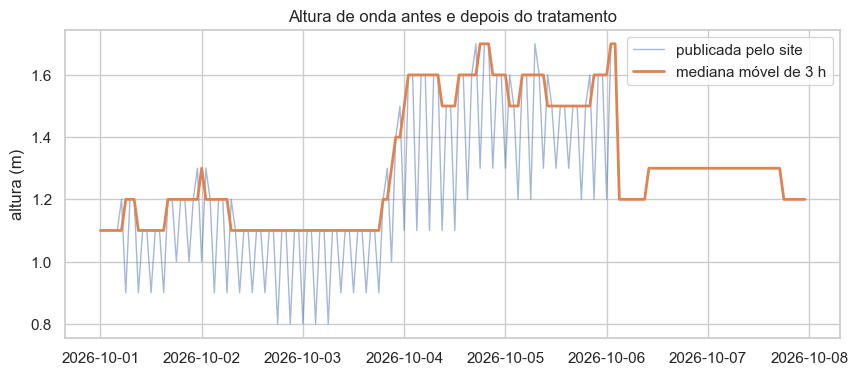

In [8]:
ondas["altura_bruta_m"] = ondas["altura_m"]
ondas["altura_m"] = ondas["altura_bruta_m"].rolling(3, center=True, min_periods=1).median()

fig, ax = plt.subplots()
ax.plot(ondas["momento"], ondas["altura_bruta_m"], lw=1, alpha=0.5, label="publicada pelo site")
ax.plot(ondas["momento"], ondas["altura_m"], lw=2, label="mediana móvel de 3 h")
ax.set(title="Altura de onda antes e depois do tratamento", ylabel="altura (m)")
ax.legend()

print(ondas.groupby(ondas["hora"] % 3)["altura_m"].mean().round(2).rename("média por hora % 3, depois"))
print(pd.crosstab(ondas["dia"], ondas["direcao_onda"]))

**Tratamento: mediana móvel de 3 horas, centrada.** Uma queda isolada entre
dois vizinhos (1,6 → 1,1 → 1,6) vira 1,6, e uma variação que dura 2 horas ou
mais é preservada. Usei mediana e não média porque a média puxaria o valor para
baixo (1,43) e criaria números que o site nunca publicou.

**Leitura.** Depois da mediana móvel, a curva fica contínua e a diferença entre
as horas múltiplas de 3 e as outras some. A coluna original foi mantida
(`altura_bruta_m`) para ser possível comparar. **Onde essa suposição erra:** se
as horas múltiplas de 3 forem as *corretas* (a saída direta do modelo) e as
outras forem as distorcidas, então estamos superestimando a onda em ~20 cm. Não
há como saber pelo site; a gente apostou que o mar varia de forma suave.

**Direção:** a onda chega quase sempre de **leste (E)**, com um pouco de ESE no
dia 01 e de NE no dia 03. A praia de João Pessoa fica de frente para o leste,
então a ondulação chega de frente, o que é bom.

### Vento

variância explicada pela hora: 16%
variância explicada pelo dia:  58%
        min  mean   max
dia                    
01/10  17.0  21.3  25.0
02/10  14.0  20.6  27.0
03/10  17.0  22.5  30.0
04/10  26.0  29.3  32.0
05/10  21.0  25.8  31.0
06/10  24.0  27.0  30.0
07/10  19.0  24.6  29.0


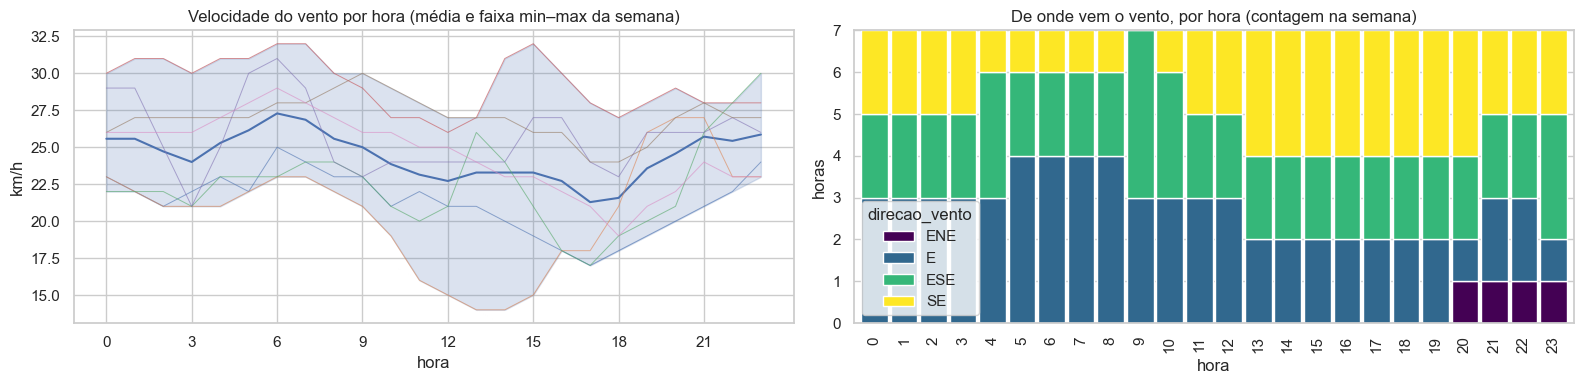

In [9]:
vento["hora"] = vento["momento"].dt.hour
vento["dia"] = vento["momento"].dt.strftime("%d/%m")

fig, ax = plt.subplots(1, 2, figsize=(16, 4))
sns.lineplot(data=vento, x="hora", y="vento_kmh", errorbar=("pi", 100), ax=ax[0])
sns.lineplot(data=vento, x="hora", y="vento_kmh", hue="dia", ax=ax[0], lw=0.7, alpha=0.6, legend=False)
ax[0].set(title="Velocidade do vento por hora (média e faixa min–max da semana)", ylabel="km/h")
ax[0].set_xticks(range(0, 24, 3))

ordem = ["ENE", "E", "ESE", "SE"]
pd.crosstab(vento["hora"], vento["direcao_vento"])[ordem].plot.bar(stacked=True, ax=ax[1], width=0.9, colormap="viridis")
ax[1].set(title="De onde vem o vento, por hora (contagem na semana)", ylabel="horas")
plt.tight_layout()

por_hora = vento.groupby("hora")["vento_kmh"].transform("mean")
por_dia = vento.groupby("dia")["vento_kmh"].transform("mean")
print(f"variância explicada pela hora: {por_hora.var() / vento['vento_kmh'].var():.0%}")
print(f"variância explicada pelo dia:  {por_dia.var() / vento['vento_kmh'].var():.0%}")
print(vento.groupby("dia")["vento_kmh"].agg(["min", "mean", "max"]).round(1))

**Leitura.**

- **O vento é forte a semana inteira:** de 14 a 32 km/h, com média de 24. Para
  surf, a partir de ~15–20 km/h o vento já começa a bagunçar a onda.
- **Hora mais calma: fim da tarde (16–18h, ~21–22 km/h). A mais ventosa: início
  da manhã (6–7h, ~27 km/h).** Mas a hora do dia explica só ~16% da variação,
  e o **dia** explica ~58%: o dia 02/10 é o mais calmo (média 20,6, com mínima de
  14) e o dia 04/10 é o mais ventoso (média 29,3).
- **Direção: 100% das horas o vento vem do mar** (ENE, E, ESE, SE). A costa
  de João Pessoa fica voltada para o leste, então vento de leste sopra do mar
  para a terra: é o *vento maral* (onshore), que empurra a crista da onda, faz
  ela quebrar antes da hora e deixa o mar "mexido". O vento bom para surf seria
  o *terral* (de oeste, da terra para o mar), que segura a onda em pé, e ele
  **não aparece em nenhuma hora da janela**. O vento vira um pouco de E (de
  manhã) para SE (à tarde e à noite), mas continua sempre vindo do mar.
- **Consequência para a pergunta:** como a direção não muda nada nesta semana,
  quem decide se o vento atrapalha mais ou menos é a **velocidade**.

## 4. Juntar as tabelas

Esta é a parte difícil, e ela tem mais de uma resposta certa.

As granularidades não batem: onda e vento são leituras horárias; maré são ~4
eventos por dia (os instantes de máxima e mínima). Para ter uma linha por hora
com as três informações você precisa decidir:

- Como levar a maré para a grade horária? Interpolar entre eventos? Repetir o
  último valor? Guardar apenas se a maré está subindo ou descendo? O que cada
  escolha assume sobre a curva real da maré — e onde essa suposição erra?
- Qual o tipo de junção? A previsão de onda e a de vento cobrem exatamente as
  mesmas horas? Se não, você mantém as horas incompletas ou corta?
- Que variáveis derivadas de tempo ajudam a responder a pergunta do projeto
  (dia da semana, período do dia, ...)?

Justifique as escolhas em markdown. Elas são a base das duas próximas etapas.

### 4.1 Onda + vento

As duas já estão na mesma grade horária (verificado na seção 2), então a
junção é direta. Uso `inner` com `validate="one_to_one"`: se algum dia as
grades deixarem de bater, o pandas falha alto em vez de duplicar ou sumir com
linhas em silêncio.

In [10]:
base = ondas[["momento", "altura_m", "altura_bruta_m", "direcao_onda"]].merge(
    vento[["momento", "vento_kmh", "direcao_vento"]],
    on="momento", how="inner", validate="one_to_one",
)
print(len(ondas), len(vento), "→", len(base), "linhas")

168 168 → 168 linhas


### 4.2 Maré na grade horária

A tábua só dá os **extremos** (os instantes de maré alta e baixa). Entre dois
extremos a água sobe ou desce, mas não em linha reta: a maré se comporta
aproximadamente como uma senoide. Começa devagar logo depois da baixa, corre
mais rápido no meio do caminho e desacelera chegando na alta. É isso que a
**regra dos doze avos** dos marinheiros descreve: nas 6 horas de enchente sobem
1/12, 2/12, 3/12, 3/12, 2/12 e 1/12 da amplitude.

Por isso escolhi a **interpolação por cosseno** entre cada par de extremos
consecutivos:

$$h(t) = h_1 + (h_2 - h_1)\,\frac{1 - \cos(\pi f)}{2}, \qquad f = \frac{t - t_1}{t_2 - t_1}$$

Comparando com as alternativas do roteiro:

| Opção | O que assume | Onde erra |
|---|---|---|
| Repetir o último valor | a água fica parada até o próximo extremo | erro de até ~1,7 m logo antes da virada |
| Interpolação linear | a água sobe a velocidade constante | subestima a velocidade no meio da enchente e a superestima perto dos extremos |
| Só subindo/descendo | só importa a direção | joga fora a altura, que muda muito de um dia para o outro |
| **Cosseno** (escolhida) | cada meia-maré é meia senoide | ver abaixo |

Além da altura, guardo **se a maré está enchendo** e a **fração do caminho**
entre baixa (0) e alta (1). A fração compara dias com amplitudes diferentes na
mesma escala.

In [11]:
def mare_horaria(momentos, eventos):
    t_ev = eventos["momento"].to_numpy()
    h_ev = eventos["altura_m"].to_numpy()
    alta_ev = (eventos["tipo"] == "alta").to_numpy()

    t = momentos.to_numpy()
    i = np.searchsorted(t_ev, t, side="right") - 1
    valido = (i >= 0) & (i < len(t_ev) - 1)
    i = np.clip(i, 0, len(t_ev) - 2)

    t1, t2 = t_ev[i], t_ev[i + 1]
    h1, h2 = h_ev[i], h_ev[i + 1]
    f = (t - t1) / (t2 - t1)
    peso = (1 - np.cos(np.pi * f)) / 2
    enchendo = alta_ev[i + 1]

    res = pd.DataFrame({
        "mare_altura_m": h1 + (h2 - h1) * peso,
        "mare_linear_m": h1 + (h2 - h1) * f,
        "mare_enchendo": enchendo.astype(float),
        "mare_fracao": np.where(enchendo, peso, 1 - peso),
    }, index=momentos.index)
    res.loc[~valido] = np.nan
    return res


base = base.join(mare_horaria(base["momento"], mares_prev))
print("horas sem maré:", base["mare_altura_m"].isna().sum())
base.loc[base["mare_altura_m"].isna(), ["momento", "altura_m", "vento_kmh"]]

horas sem maré: 1


,momento,altura_m,vento_kmh
0,2026-10-01,1.1,23.0


Uma hora ficou sem maré: **01/10 às 00:00**. O primeiro evento coletado é a
baixa de 00:24 desse dia, e o extremo anterior é de 30/09, que não está no
`mares_previsao.csv`. Não dá para interpolar sem os dois lados, e extrapolar
seria inventar dado. Como é uma hora só e é de madrugada (ninguém surfa à
meia-noite), **descarto a linha**. Se a janela começasse mais tarde, o
scraper deveria pedir também o mês anterior.

diferença cosseno × linear: média 0.10 m, máxima 0.20 m


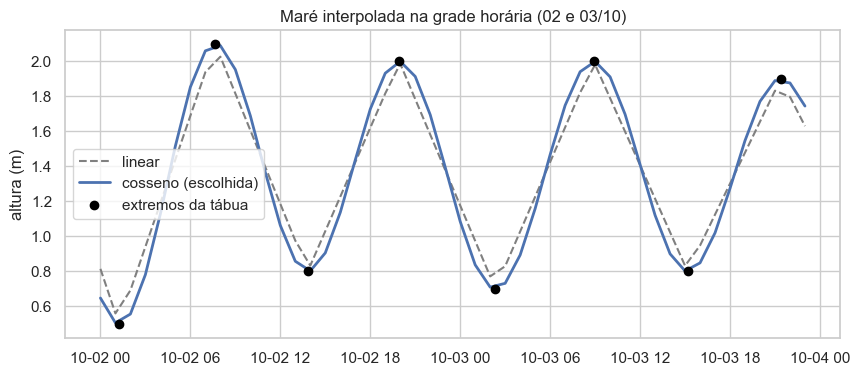

In [12]:
base = base.dropna(subset=["mare_altura_m"]).reset_index(drop=True)
base["mare_enchendo"] = base["mare_enchendo"].astype(bool)

janela = (base["momento"] >= "2026-10-02") & (base["momento"] < "2026-10-04")
ev = mares_prev[(mares_prev["momento"] >= "2026-10-02") & (mares_prev["momento"] < "2026-10-04")]

fig, ax = plt.subplots()
ax.plot(base.loc[janela, "momento"], base.loc[janela, "mare_linear_m"], ls="--", color="gray", label="linear")
ax.plot(base.loc[janela, "momento"], base.loc[janela, "mare_altura_m"], lw=2, label="cosseno (escolhida)")
ax.scatter(ev["momento"], ev["altura_m"], color="black", zorder=3, label="extremos da tábua")
ax.set(title="Maré interpolada na grade horária (02 e 03/10)", ylabel="altura (m)")
ax.legend()

dif = (base["mare_altura_m"] - base["mare_linear_m"]).abs()
print(f"diferença cosseno × linear: média {dif.mean():.2f} m, máxima {dif.max():.2f} m")

**Onde a suposição do cosseno erra.**

- A maré real não é uma senoide perfeita. Em águas rasas a enchente e a
  vazante podem ter durações diferentes, então a curva fica assimétrica. O
  cosseno força a simetria.
- Os extremos da tábua são arredondados (hora em minutos, altura em 0,1 m), e
  esse erro passa para a interpolação.
- É a maré astronômica (calculada). Vento forte e ondulação empilham água na
  costa e mudam o nível real, o que a tábua não vê.

Mesmo assim, o erro do cosseno é bem menor que o das outras opções. Em relação
à linear, a diferença chega a ~0,2 m, justamente nos trechos perto dos
extremos, onde a linear é mais errada.

### 4.3 Informação do dia e variáveis de tempo

Coeficiente, idade da lua e horário do sol são do **dia**: entram por junção
pela data (`many_to_one`, muitas horas para um dia). Daí derivo:

- `de_dia`: se a hora está entre o nascer e o pôr do sol. É a variável mais
  prática da tabela, porque não adianta recomendar onda boa às 2h da manhã.
- `hora` e `periodo` (madrugada / manhã / tarde / noite): para responder "qual
  o melhor horário".
- `dia_semana`: Felipe e Nicholas vêm de fora, então fim de semana pode pesar.

In [13]:
info_dia = mares_prev.drop_duplicates("data")[["data", "coeficiente", "idade_lua", "nascer_sol", "por_sol"]]

base["data"] = base["momento"].dt.normalize()
base = base.merge(info_dia, on="data", how="left", validate="many_to_one")

base["hora"] = base["momento"].dt.hour
base["dia_semana"] = base["momento"].dt.dayofweek.map(dict(enumerate(["seg", "ter", "qua", "qui", "sex", "sáb", "dom"])))
base["periodo"] = pd.cut(base["hora"], bins=[-1, 4, 11, 17, 23], labels=["madrugada", "manhã", "tarde", "noite"])
base["de_dia"] = (base["momento"] >= base["nascer_sol"]) & (base["momento"] <= base["por_sol"])

print(base.isna().sum().loc[lambda s: s > 0].to_dict() or "sem nulos")
print("horas de dia:", base["de_dia"].sum(), "de", len(base))
base.head()

sem nulos
horas de dia: 87 de 167


,momento,altura_m,altura_bruta_m,direcao_onda,vento_kmh,direcao_vento,mare_altura_m,mare_linear_m,mare_enchendo,mare_fracao,data,coeficiente,idade_lua,nascer_sol,por_sol,hora,dia_semana,periodo,de_dia
0,2026-10-01 01:00:00,1.1,1.1,ESE,22.0,E,0.441549,0.579528,True,0.021868,2026-10-01,64,19,2026-10-01 05:02:00,2026-10-01 17:15:00,1,qui,madrugada,False
1,2026-10-01 02:00:00,1.1,1.1,ESE,21.0,E,0.682416,0.878740,True,0.148640,2026-10-01,64,19,2026-10-01 05:02:00,2026-10-01 17:15:00,2,qui,madrugada,False
2,2026-10-01 03:00:00,1.1,1.1,ESE,22.0,E,1.083379,1.177953,True,0.359673,2026-10-01,64,19,2026-10-01 05:02:00,2026-10-01 17:15:00,3,qui,madrugada,False
3,2026-10-01 04:00:00,1.1,1.1,ESE,23.0,E,1.548282,1.477165,True,0.604359,2026-10-01,64,19,2026-10-01 05:02:00,2026-10-01 17:15:00,4,qui,madrugada,False
4,2026-10-01 05:00:00,1.1,1.2,ESE,22.0,E,1.965634,1.776378,True,0.824018,2026-10-01,64,19,2026-10-01 05:02:00,2026-10-01 17:15:00,5,qui,manhã,False


## 5. Visualizações voltadas à pergunta

Agora com a tabela junta: quando as condições coincidem?

- As horas de onda maior são as mesmas de vento mais fraco, ou elas se
  desencontram?
- Existe relação visível entre altura da maré e altura da onda?
- Quais dias e horas da janela se destacam?

Prefira poucos gráficos legíveis a muitos gráficos.

Daqui em diante olho só as **horas de dia** (`de_dia`), que são as que interessam para surfar.

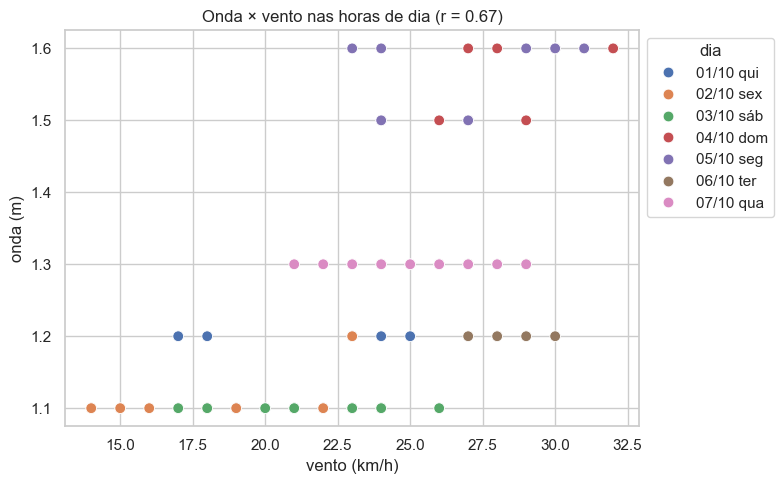

In [14]:
dia = base[base["de_dia"]].copy()
dia["dia"] = dia["momento"].dt.strftime("%d/%m ") + dia["dia_semana"]

fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=dia, x="vento_kmh", y="altura_m", hue="dia", s=60, ax=ax)
r = dia["altura_m"].corr(dia["vento_kmh"])
ax.set(title=f"Onda × vento nas horas de dia (r = {r:.2f})", xlabel="vento (km/h)", ylabel="onda (m)")
ax.legend(title="dia", bbox_to_anchor=(1, 1))
plt.tight_layout()

**Leitura: elas se desencontram.** Onda e vento têm correlação de **+0,67**:
as horas de onda maior são justamente as de vento mais forte. Os pontos de
04 e 05/10 ficam no canto de cima à direita (onda de ~1,5 m, vento de
23–32 km/h), e os de 01 a 03/10 ficam embaixo à esquerda (~1,1 m, 14–22 km/h).
O canto que o surfista quer, **onda grande com vento fraco** (em cima à
esquerda), está **vazio** nesta semana. Faz sentido físico: é o mesmo vento
alísio de leste que levanta a ondulação e que sopra na praia. Por isso a
definição de "condição boa" na Etapa 3 vai ser sempre uma troca entre os dois.

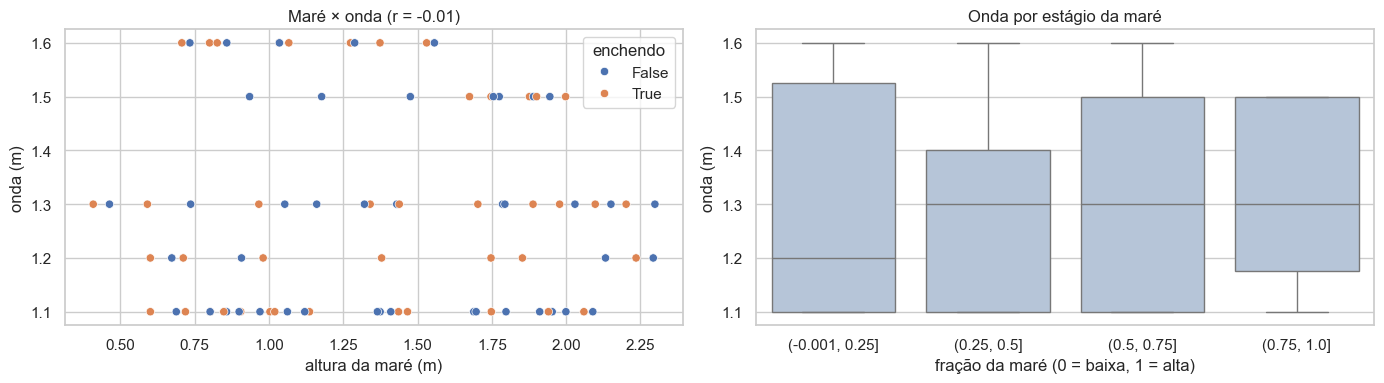

In [15]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.scatterplot(data=dia, x="mare_altura_m", y="altura_m", hue="mare_enchendo", ax=ax[0])
r = dia["altura_m"].corr(dia["mare_altura_m"])
ax[0].set(title=f"Maré × onda (r = {r:.2f})", xlabel="altura da maré (m)", ylabel="onda (m)")
ax[0].legend(title="enchendo")

sns.boxplot(data=dia, x=pd.cut(dia["mare_fracao"], [0, 0.25, 0.5, 0.75, 1], include_lowest=True), y="altura_m", ax=ax[1], color="lightsteelblue")
ax[1].set(title="Onda por estágio da maré", xlabel="fração da maré (0 = baixa, 1 = alta)", ylabel="onda (m)")
plt.tight_layout()

**Leitura: não há relação visível** (r ≈ 0,05). A onda tem a mesma
distribuição na baixa, no meio e na alta, enchendo ou vazando. Isso já era
esperado, e é importante entender por quê: a previsão de onda é calculada em
alto-mar e **não leva a maré em conta**. Na praia, a maré não muda o tamanho
da ondulação que chega; ela muda **como a onda quebra** (com pouca água ela
fecha de uma vez, com água demais ela "enche" e não quebra). Ou seja, o papel
da maré na qualidade do surf **não está nestes dados**. Se ela entrar na regra
da Etapa 3, vai ser por conhecimento de surf, declarado como suposição, e não
por algo que a EDA mostrou.

,onda_media,vento_medio,vento_min
dia,,,
01/10 qui,1.1,21.2,17.0
02/10 sex,1.1,18.2,14.0
03/10 sáb,1.1,21.8,17.0
04/10 dom,1.6,29.2,26.0
05/10 seg,1.5,25.8,23.0
06/10 ter,1.3,27.4,24.0
07/10 qua,1.3,25.2,21.0


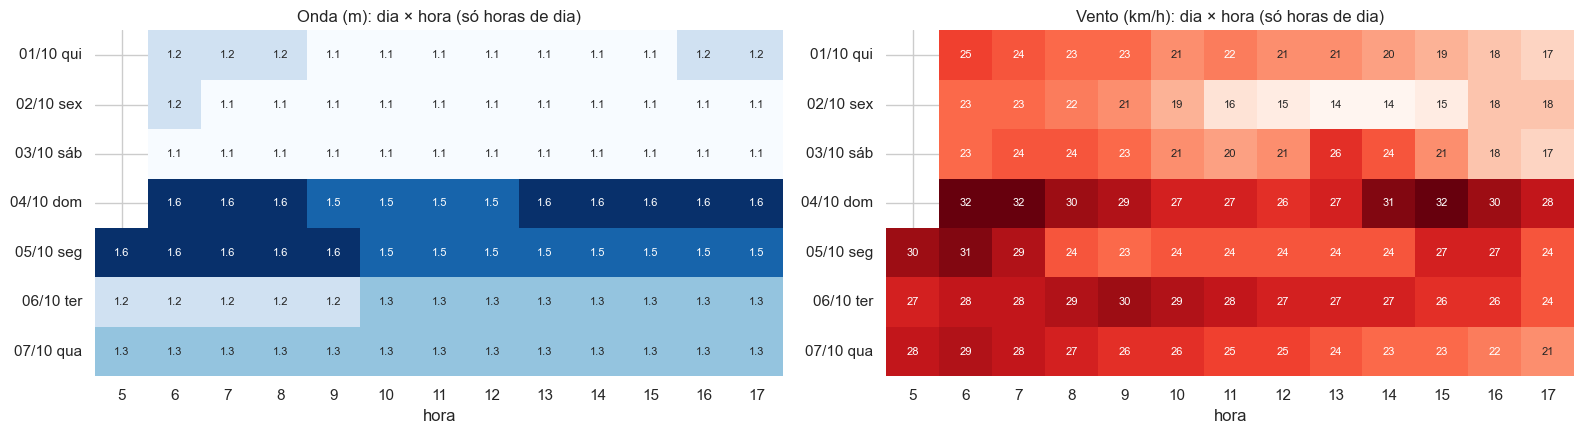

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(16, 4.5))
for a, col, titulo, cmap in [
    (ax[0], "altura_m", "Onda (m)", "Blues"),
    (ax[1], "vento_kmh", "Vento (km/h)", "Reds"),
]:
    tab = dia.pivot_table(index="dia", columns="hora", values=col)
    sns.heatmap(tab, annot=True, fmt=".1f" if col == "altura_m" else ".0f", cmap=cmap, cbar=False, ax=a, annot_kws={"size": 8})
    a.set(title=f"{titulo}: dia × hora (só horas de dia)", xlabel="hora", ylabel="")
plt.tight_layout()

dia.groupby("dia").agg(
    onda_media=("altura_m", "mean"), vento_medio=("vento_kmh", "mean"), vento_min=("vento_kmh", "min")
).round(1)

**Leitura: quais dias e horas se destacam.**

- **04/10 (dom) e 05/10 (seg)** têm a maior onda da semana (~1,55 m de média
  durante o dia), mas também o vento mais forte (26–32 km/h no domingo).
- **02/10 (sex)** tem o vento mais fraco da semana (18 km/h de média, chegando
  a 14 km/h no início da tarde), mas onda pequena (~1,1 m).
- **06 e 07/10** ficam no meio, com ~1,3 m e vento de 21–27 km/h, mas são os
  dias mais distantes da previsão e, como vimos, os menos detalhados.
- **Por hora**, a onda praticamente não muda dentro do dia, e o vento
  tende a cair ao longo dele: em 4 dos 7 dias o vento mais fraco é às 17h. Não
  é regra (no dia 02 o mínimo é às 13–14h e no dia 05 às 9h), então o dia pesa
  mais que a hora.

Não existe um momento que ganhe em tudo. Qual deles é "o melhor" depende de
quanto peso se dá à onda contra o vento, e essa é a decisão da Etapa 3.

## 6. Salvar o dataset processado

Grave o resultado em `../data/processed/dataset.csv`. A Etapa 3 lê esse
arquivo — se as colunas mudarem depois, o notebook de ML muda também.

In [17]:
colunas = [
    "momento", "data", "dia_semana", "hora", "periodo", "de_dia",
    "altura_m", "altura_bruta_m", "direcao_onda",
    "vento_kmh", "direcao_vento",
    "mare_altura_m", "mare_enchendo", "mare_fracao",
    "coeficiente", "idade_lua",
]
dataset = base[colunas].round({"mare_altura_m": 2, "mare_fracao": 3})
dataset.to_csv(DIR_PROC / "dataset.csv", index=False)
print(dataset.shape)
dataset.dtypes

(167, 16)


momento           datetime64[us]
data              datetime64[us]
dia_semana                   str
hora                       int32
periodo                 category
de_dia                      bool
altura_m                 float64
altura_bruta_m           float64
direcao_onda                 str
vento_kmh                float64
direcao_vento                str
mare_altura_m            float64
mare_enchendo               bool
mare_fracao              float64
coeficiente                int64
idade_lua                  int64
dtype: object

O dataset guarda **todas as 167 horas**, e não só as de dia. A coluna
`de_dia` deixa a Etapa 3 decidir o filtro. Ficaram de fora a maré linear (só
servia para comparar) e os horários do sol (já resumidos em `de_dia`).
`altura_m` é a onda **tratada** (mediana móvel), e `altura_bruta_m` é a
publicada pelo site.

## 7. Conclusões

**1. O que os dados mostram sobre a janela (01 a 07/10/2026).**
A semana inteira tem onda de 1,1 a 1,6 m vindo de leste, de frente para a
praia, o que é bom, e vento sempre de leste/sudeste, ou seja, **maral** (do mar
para a terra), forte (14 a 32 km/h), o que é ruim. Em nenhuma hora sopra o
terral, que é o vento que deixa a onda bonita. Onda e vento sobem juntos
(r = 0,67) porque vêm do mesmo sistema de alísios, então **não existe a
combinação ideal nesta semana**: os dias de onda maior (04 e 05/10) são os
mais ventosos, e o dia de vento mais fraco (02/10) tem a menor onda. A maré
segue o ciclo da lua (coeficiente alto na lua nova e na cheia), mas não tem
relação com a altura da onda prevista.

**2. A decisão que mais influencia o resultado.**
O **tratamento da onda**. O site publica um serrilhado artificial a cada 3
horas (valores ~20 cm menores), e a mediana móvel o remove. Sem esse
tratamento, qualquer ranking por hora ficaria viciado: as horas 0, 3, 6, 9...
sairiam sempre piores por um defeito de publicação, e não por causa do mar. A
segunda decisão é a **interpolação da maré por cosseno**, que muda a altura da
maré em até 0,2 m em relação à linear, justamente perto dos extremos.

**3. O que estes dados não permitem afirmar.**
- **Nada sobre a época do ano.** Onda e vento cobrem 7 dias, e só a maré tem
  histórico. Responder "qual o melhor mês" exigiria uma série longa de onda e
  vento: rodar o scraper todo dia por um ano, ou usar uma fonte com histórico
  (reanálises de ondas).
- **Nada sobre qualidade de onda além da altura.** O site não publica o
  **período** da onda (segundos entre uma onda e outra), que é o que separa um
  swell organizado de um mar picado de vento. Também não há rajadas.
- **Nada sobre o efeito real da maré no surf.** Ele depende do fundo de cada
  pico (bancada, areia), que não está em nenhum dado.
- **Pouca confiança nos últimos dias da janela:** a previsão perde resolução
  a partir de 06/10.
- E tudo isto é **previsão**, não medição: o mar que vai acontecer pode ser
  diferente.